# Corrections

`phoptic` provides a simple interface for creating and applying image corrections via the `phoptic.correctors` subpackge. Currently, corrections are limited to bias, flat-fields and darks. However, we plan to implement a flexible framework for applying bespoke corrections in future.

In this notebook, I will demonstrate how to create a correction image, and how this correction image can be incorporated into the reduction process.

## Flat-fielding

First, let's take a look at flat-field corrections.

### Generating Synthetic Data and Flats

Before applying flat-field corrections, we need some flat-field images. For this tutorial, I will use the `generate_flats()` routine to generate some synethetic flats. I will also generate some synthetic observations using `generate_observations()` with `circular_aperture=True`:

In [1]:
from pathlib import Path

import phoptic

out_dir = Path('out')
obs_dir = out_dir / 'data' / 'observations'
flats_dir = out_dir / 'calibration_images' / 'flats'

phoptic.generate_observations(
    out_directory=obs_dir,
    n_images=10,  # number of images per camera
    circular_aperture=True,  # impose circular aperture shadow on images
    )

phoptic.generate_flats(
    out_directory=flats_dir,
    n_flats=5,  # number of flats per camera
)

[OPTICAM] variable source is at (131, 115)
[OPTICAM] variability RMS: 0.02 %
[OPTICAM] variability frequency: 0.135 Hz
[OPTICAM] variability phase lags:
    [OPTICAM] g-band: 0.000 radians
    [OPTICAM] r-band: 1.571 radians
    [OPTICAM] i-band: 3.142 radians


Generating observations:   0%|                                                                                                                                        |[00:00<?]

Generating observations:  10%|█████████████▏                                                                                                                      |[00:00<00:01]

Generating observations:  20%|██████████████████████████▍                                                                                                         |[00:00<00:01]

Generating observations:  30%|███████████████████████████████████████▌                                                                                            |[00:00<00:00]

...

Generating flats:  40%|███████████████████████████████████████████████████████▌                                                                                   |[00:00<00:01]

Generating flats:  60%|███████████████████████████████████████████████████████████████████████████████████▍                                                       |[00:01<00:00]

Generating flats:  80%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                           |[00:01<00:00]

Generating flats: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:01<00:00]

Generating flats: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:01<00:00]

Let's check the files in the newly created flats directory:

In [2]:
flat_paths = sorted(list(flats_dir.glob('*')))

flat_paths

[PosixPath('out/calibration_images/flats/g-band_image_0.fits.gz'),
 PosixPath('out/calibration_images/flats/g-band_image_1.fits.gz'),
 PosixPath('out/calibration_images/flats/g-band_image_2.fits.gz'),
 PosixPath('out/calibration_images/flats/g-band_image_3.fits.gz'),
 PosixPath('out/calibration_images/flats/g-band_image_4.fits.gz'),
 PosixPath('out/calibration_images/flats/i-band_image_0.fits.gz'),
 PosixPath('out/calibration_images/flats/i-band_image_1.fits.gz'),
 PosixPath('out/calibration_images/flats/i-band_image_2.fits.gz'),
 PosixPath('out/calibration_images/flats/i-band_image_3.fits.gz'),
 PosixPath('out/calibration_images/flats/i-band_image_4.fits.gz'),
 PosixPath('out/calibration_images/flats/r-band_image_0.fits.gz'),
 PosixPath('out/calibration_images/flats/r-band_image_1.fits.gz'),
 PosixPath('out/calibration_images/flats/r-band_image_2.fits.gz'),
 PosixPath('out/calibration_images/flats/r-band_image_3.fits.gz'),
 PosixPath('out/calibration_images/flats/r-band_image_4.fits.g

We have a total of 15 flats in three different filters, matching the three filters of our synthetic observations.

Let's take a look at one of our newly-generated flats:

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  512                                                  
NAXIS2  =                  512                                                  
EXTEND  =                    T                                                  
FILTER  = 'g       '                                                            
EXPOSURE=                 0.05                                                  
BINNING = '4x4     '                                                            
GAIN    =                  1.0                                                  
INSTRUME= 'OPTICAM '                                                            
AIRMASS =                    1                                                  
UT      = '2024-01-01 00:00:

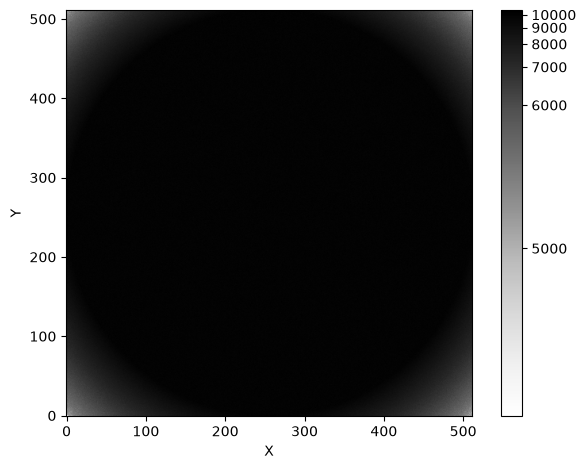

In [3]:
from astropy.io import fits
from astropy.visualization import simple_norm
from matplotlib import pyplot as plt
import numpy as np


# open the first flat field image
with fits.open(flat_paths[0]) as hdul:
    print(repr(hdul[0].header))
    flat = np.array(hdul[0].data)

# plot the flat field image
fig, ax = plt.subplots(tight_layout=True)

im = ax.imshow(
    flat,
    norm=simple_norm(
        flat,
        stretch="log",
        ),
    origin="lower",
    cmap="Greys",
    )

fig.colorbar(im)

ax.set_xlabel("X")
ax.set_ylabel("Y")

plt.show()

These synthetic flats show a circular shadow. You might imagine that this shadow was cast by the telescope's circular aperture.

We see a similar shadow in the synthetic observations:

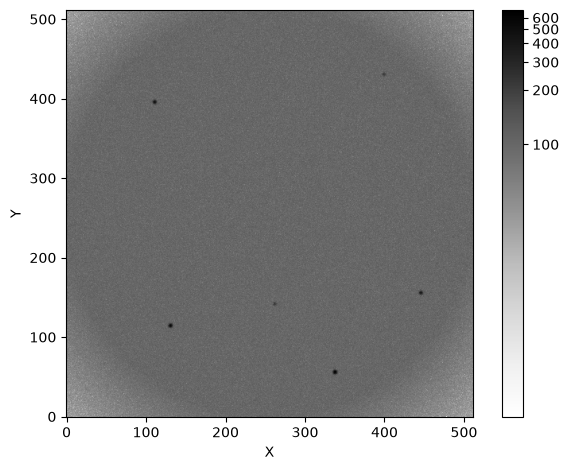

In [4]:
# get the first image
image_paths = sorted(list(obs_dir.glob('*')))

# open the image
with fits.open(image_paths[0]) as hdul:
    image = np.array(hdul[0].data)

# plot the image
fig, ax = plt.subplots(tight_layout=True)

im = ax.imshow(
    image,
    norm=simple_norm(
        image,
        stretch="log",
        ),
    origin="lower",
    cmap="Greys",
    )

fig.colorbar(im)

ax.set_xlabel("X")
ax.set_ylabel("Y")

plt.show()

Just like in the flats, we see a circular shadow at the corners of the image.

### Ignoring flat-field corrections

Let's see what happens if we neglect flat-field corrections:

[OPTICAM] out/reduced/no_flats not found, attempting to create ...
[OPTICAM] out/reduced/no_flats created.


[OPTICAM] Scanning data directory:   0%|                                                                                                                              |[00:00<?]

[OPTICAM] Scanning data directory: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:00<00:00]

[OPTICAM] Checking instrument OPTICAM_MX.


[OPTICAM] OPTICAM_MX sucessfully passed all checks.


...

[OPTICAM] Filters: 1:g, 2:r, 3:i


[OPTICAM] 10 1:g images.


[OPTICAM] 10 2:r images.


[OPTICAM] 10 3:i images.


[OPTICAM] Plot saved to /tmp/tmpfoyp37uw/out/reduced/no_flats/diag/header_times.pdf.


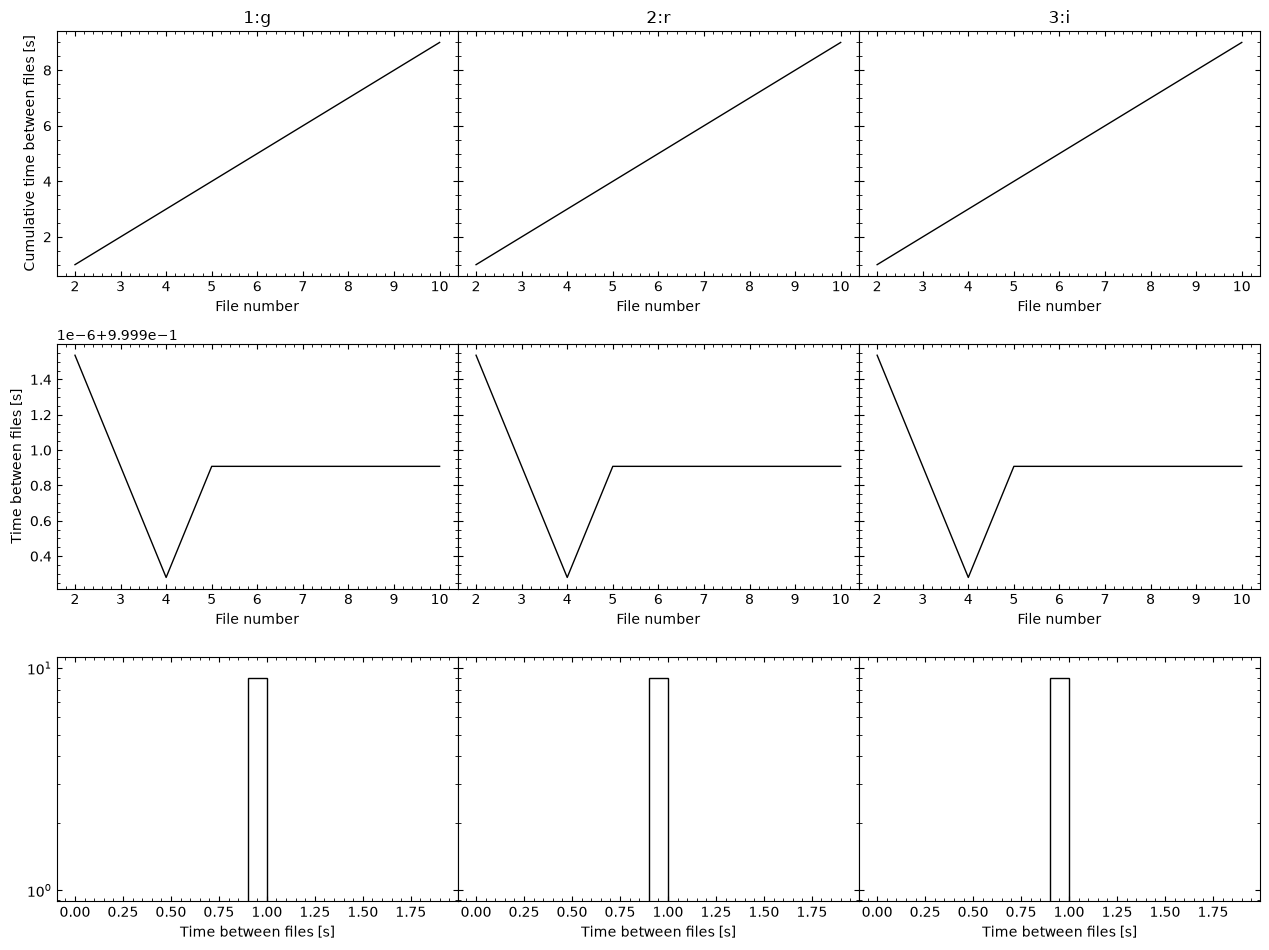

[OPTICAM] Creating source catalogs.


[OPTICAM] Aligning 1:g images:   0%|                                                                                                                                  |[00:00<?]

[OPTICAM] Aligning 1:g images:  10%|████████████▌                                                                                                                 |[00:02<00:24]

[OPTICAM] Aligning 1:g images: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:02<00:00]

[OPTICAM] [OPTICAM] Done.


...

[OPTICAM] Aligning 3:i images: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:02<00:00]

[OPTICAM] [OPTICAM] Done.


[OPTICAM] [OPTICAM] 10 image(s) aligned.


[OPTICAM] [OPTICAM] 0 image(s) could not be aligned.


[OPTICAM] Plot saved to /tmp/tmpfoyp37uw/out/reduced/no_flats/cat/catalogs.pdf.


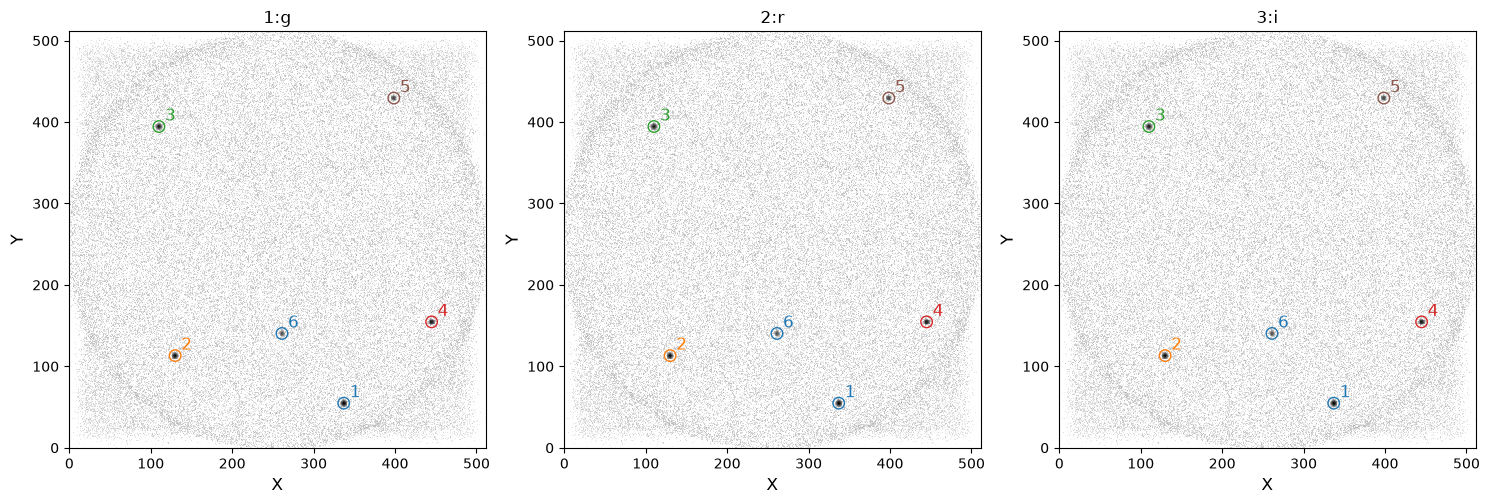

[OPTICAM] Plot saved to /tmp/tmpfoyp37uw/out/reduced/no_flats/diag/systematics.pdf.


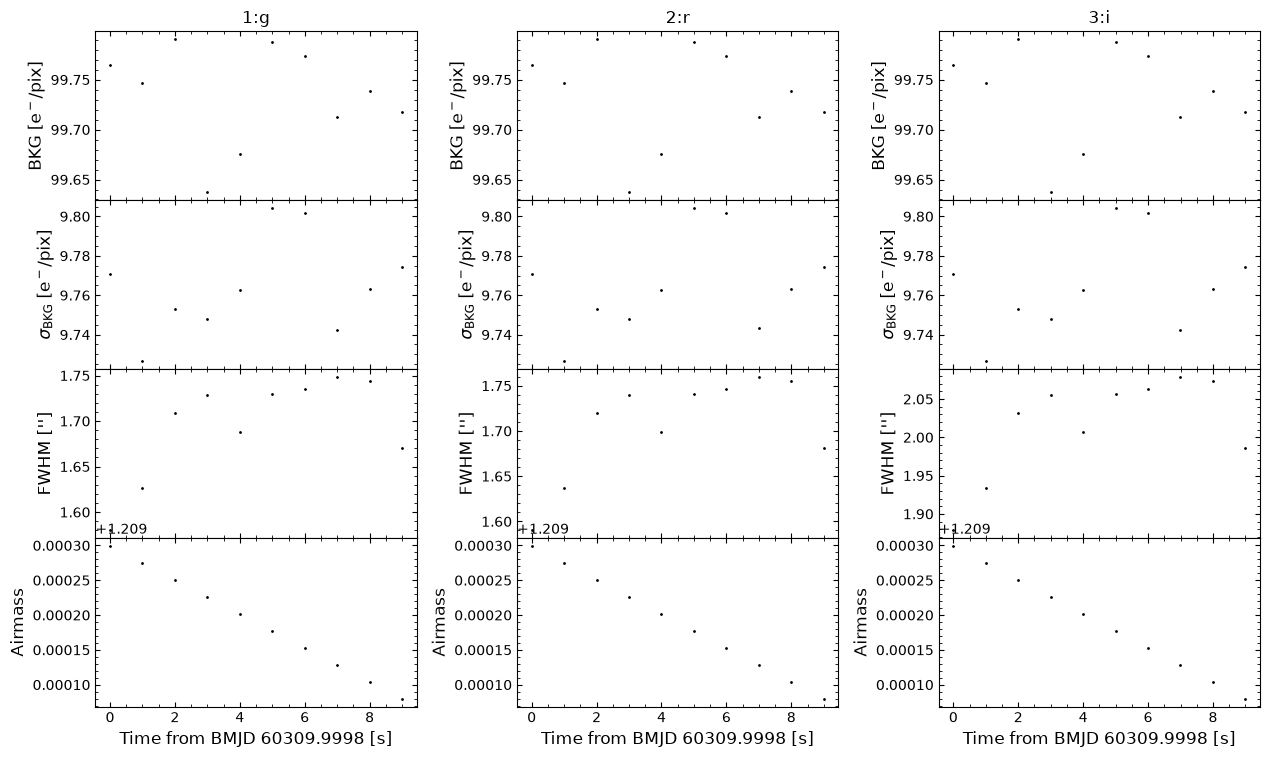

In [5]:
reducer = phoptic.Reducer(
    data_directory=obs_dir,  # path to the simulated data
    out_directory=out_dir / 'reduced' / 'no_flats',  # path to where output will be saved
    show_plots=True,
    )

reducer.create_catalogs()

As we can see, systematic artefacts stack in the catalog image. Not only can these artefacts skew flux measurements, but they may also lead to spurious source detections. It's therefore important to correct for these effects.

### Applying Flat-field Corrections

In `phoptic`, flat-field corrections are handled by an `phoptic.FlatFieldCorrector` object:

In [6]:
flat_corrector = phoptic.FlatFieldCorrector(
    out_directory=out_dir / 'correctors' / 'manual_flats',  # where the master flat field images will be stored
    data_directory=flats_dir,  # where the flat field images are stored
    )

[OPTICAM] Scanning data directory:   0%|                                                                                                                              |[00:00<?]

[OPTICAM] Scanning data directory:  67%|█████████████████████████████████████████████████████████████████████████████████▎                                        |[00:00<00:00]

[OPTICAM] Scanning data directory: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:00<00:00]

[OPTICAM] 5 1:g flat-field images.
[OPTICAM] 5 3:i flat-field images.
[OPTICAM] 5 2:r flat-field images.


When defining a `FlatFieldCorrector` object, an `out_directory` must be specified. This is the directory to which any output files (e.g., the master flats) will be written. 

After creating a `FlatFieldCorrector` instance, you will be able to see how many flats have been detected for each filter. In this case, we can see that each filter has five flat-field images.

#### Creating Master Flats (Long Way)

Now that we have a `FlatFieldCorrector` instance, we can either create master flats manually, or pass the `FlatFieldCorrector` object to a `Reducer` instance, which will automatically create the master flats for us as required. In this example, let's create the master flats manually using the `create_master_images()` method:

In [7]:
flat_corrector.create_master_images()

[OPTICAM] Master flat-field image(s) created.


[OPTICAM] Master flat-field image(s) saved to out/correctors/manual_flats/master_flats.fits.gz.


For convenience, the location of the resulting master flats file is displayed once it has been created. This is a single FITS file that may contain several master flats. In this case, it should contain three images. 

We can either read the master flats from their new directory, or access them directly from the `FlatFieldCorrector` instance using the `master_images` attribute. Let's first look at the file:

In [8]:
from astropy.io import fits

with fits.open(flat_corrector.master_image_path) as hdul:
    for hdu in hdul:
        print(repr(hdu.header))
        print()

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
COMMENT This FITS file contains master flat-field images and their corresponding
COMMENT  variances for each filter.                                             

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  512                                                  
NAXIS2  =                  512                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                  

In the master flats file, we can see that the first header-data unit (HDU) is blank. The remaining HDUs contain the master flat-field images for each filter and their master variance images (for error propagation). Let's now take a look at one of these master flats using the `master_images` attribute of the `FlatFieldCorrector` instance:

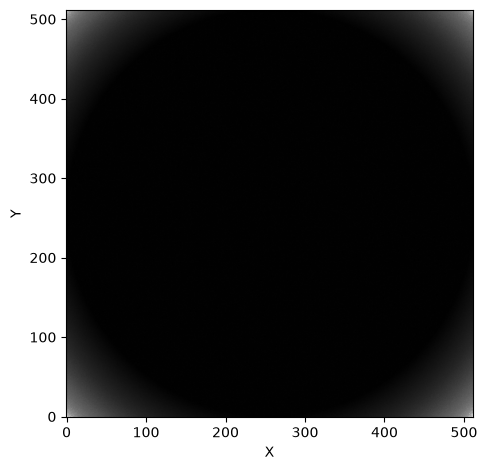

In [9]:
master_flat = flat_corrector.master_images['1:g']

fig, ax = plt.subplots(tight_layout=True)

im = ax.imshow(
    master_flat,
    norm=simple_norm(
        master_flat,
        stretch="log",
        ),
    origin="lower",
    cmap="Greys",
    )

ax.set_xlabel("X")
ax.set_ylabel("Y")

plt.show()

### Performing Flat-field Corrections

Let's now use our `FlatFieldCorrector` instance to correct an image using its `correct()` method. `correct()` takes an image array and its corresponding filter as input, and then returns the corrected image and the variance introduced from the correction (used in error propagation):

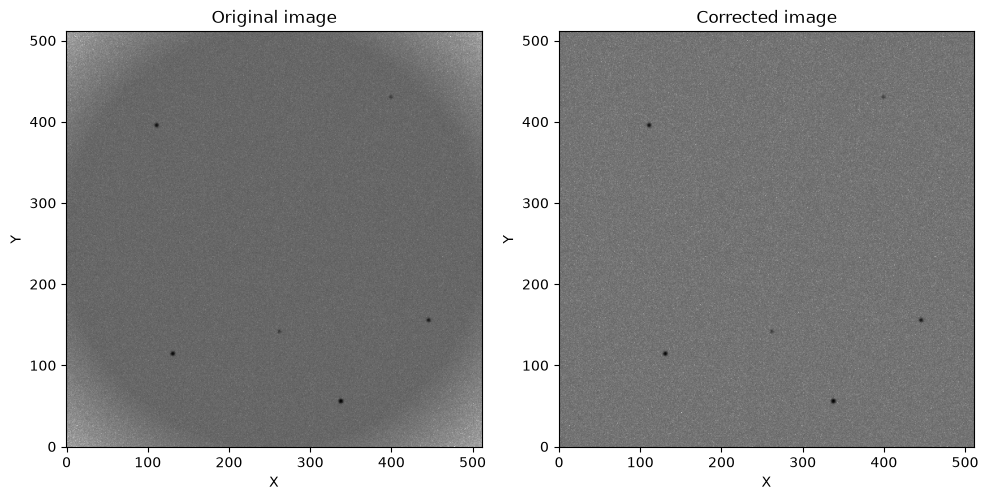

In [10]:
with fits.open(image_paths[0]) as hdul:
    fltr = hdul[0].header['FILTER']
    image = np.array(hdul[0].data)

if fltr == 'g':
    camera = '1'
elif fltr == 'r':
    camera = '2'
elif fltr == 'i':
    camera = '3'

# apply the flat-field correction
corrected_image, flat_var = flat_corrector.correct(image, camera=camera, fltr=fltr)

fig, axes = plt.subplots(
    ncols=2,
    tight_layout=True,
    figsize=(10, 5),
    )

axes[0].imshow(
    image,
    norm=simple_norm(
        image,
        stretch="log",
        ),
    origin="lower",
    cmap="Greys",
    )
axes[0].set_title('Original image')

axes[1].imshow(
    corrected_image,
    norm=simple_norm(
        corrected_image,
        stretch="log",
        ),
    origin="lower",
    cmap="Greys",
    )
axes[1].set_title('Corrected image')

for ax in axes:
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

plt.show()

As we can see, the aperture shadow has been successfully removed!

We can automate the process of applying master flats by passing an `phoptic.FlatFieldCorrector` instance to `phoptic.Reducer`:

[OPTICAM] out/reduced/manual_flats not found, attempting to create ...
[OPTICAM] out/reduced/manual_flats created.


[OPTICAM] Scanning data directory:   0%|                                                                                                                              |[00:00<?]

[OPTICAM] Scanning data directory: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:00<00:00]

[OPTICAM] Checking instrument OPTICAM_MX.
[OPTICAM] OPTICAM_MX sucessfully passed all checks.


[OPTICAM] Parsing file headers:   0%|                                                                                                                                 |[00:00<?]

...

[OPTICAM] 10 1:g images.


[OPTICAM] 10 2:r images.


[OPTICAM] 10 3:i images.


[OPTICAM] FlatFieldCorrector sucessfully passed all checks.


[OPTICAM] Plot saved to /tmp/tmpfoyp37uw/out/reduced/manual_flats/diag/header_times.pdf.


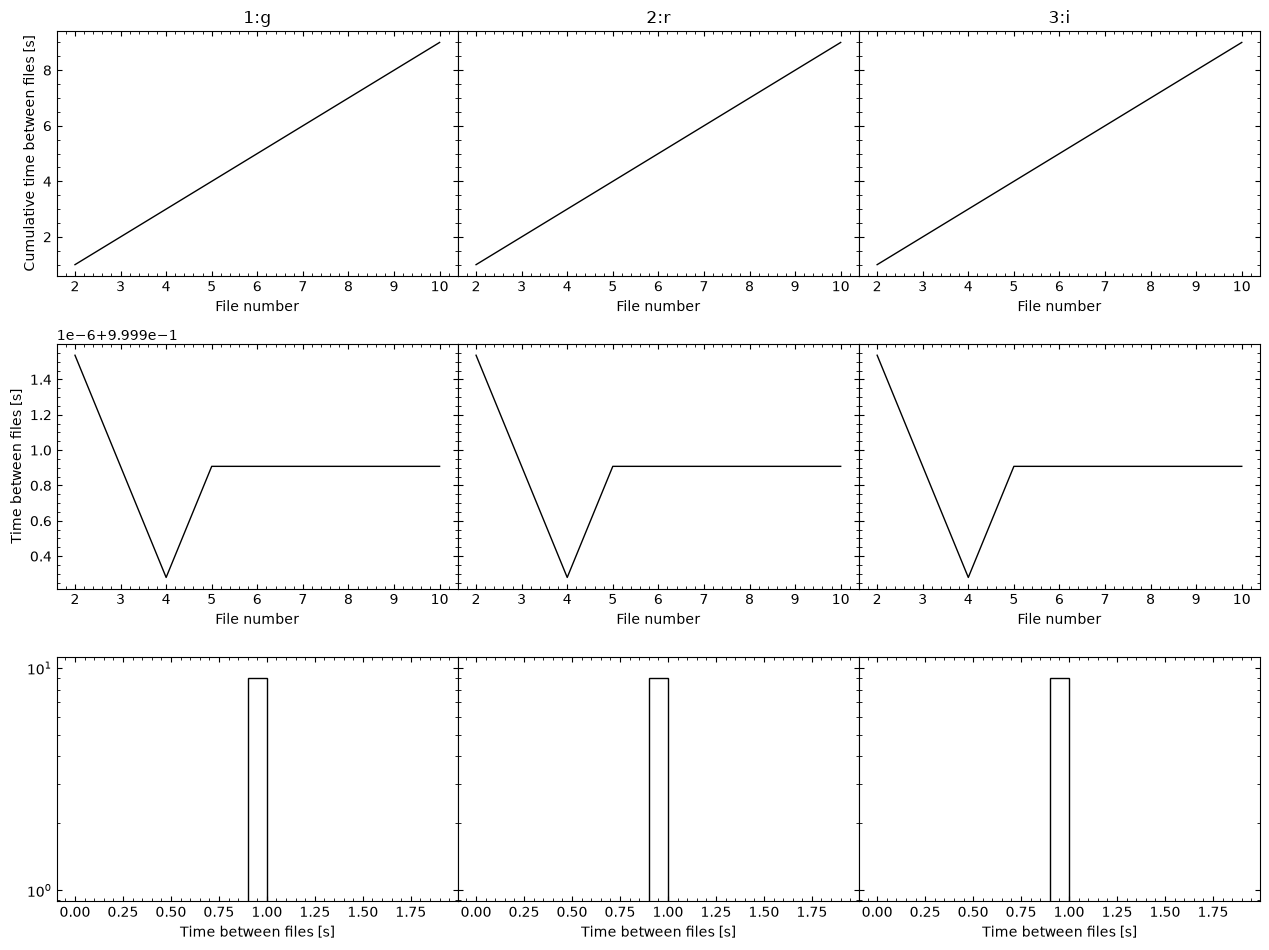

In [11]:
reducer = phoptic.Reducer(
    data_directory=obs_dir,  # path to the simulated data
    out_directory=out_dir / 'reduced' / 'manual_flats',  # path to where output will be saved
    show_plots=True,
    flat_corrector=flat_corrector,  # pass the flat field corrector
    )

After initialising our `Reducer`, we are told that our `FlatFieldCorrector` successfully passed all checks. This is a safety measure to ensure that the binnings of the flat-field images match those of the science images. Let's now create source catalogs:

[OPTICAM] Creating source catalogs.


[OPTICAM] Aligning 1:g images:   0%|                                                                                                                                  |[00:00<?]

[OPTICAM] Aligning 1:g images:  10%|████████████▌                                                                                                                 |[00:02<00:24]

[OPTICAM] Aligning 1:g images: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:02<00:00]

[OPTICAM] [OPTICAM] Done.


...

[OPTICAM] Aligning 3:i images: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:03<00:00]

[OPTICAM] [OPTICAM] Done.


[OPTICAM] [OPTICAM] 10 image(s) aligned.


[OPTICAM] [OPTICAM] 0 image(s) could not be aligned.


[OPTICAM] Plot saved to /tmp/tmpfoyp37uw/out/reduced/manual_flats/cat/catalogs.pdf.


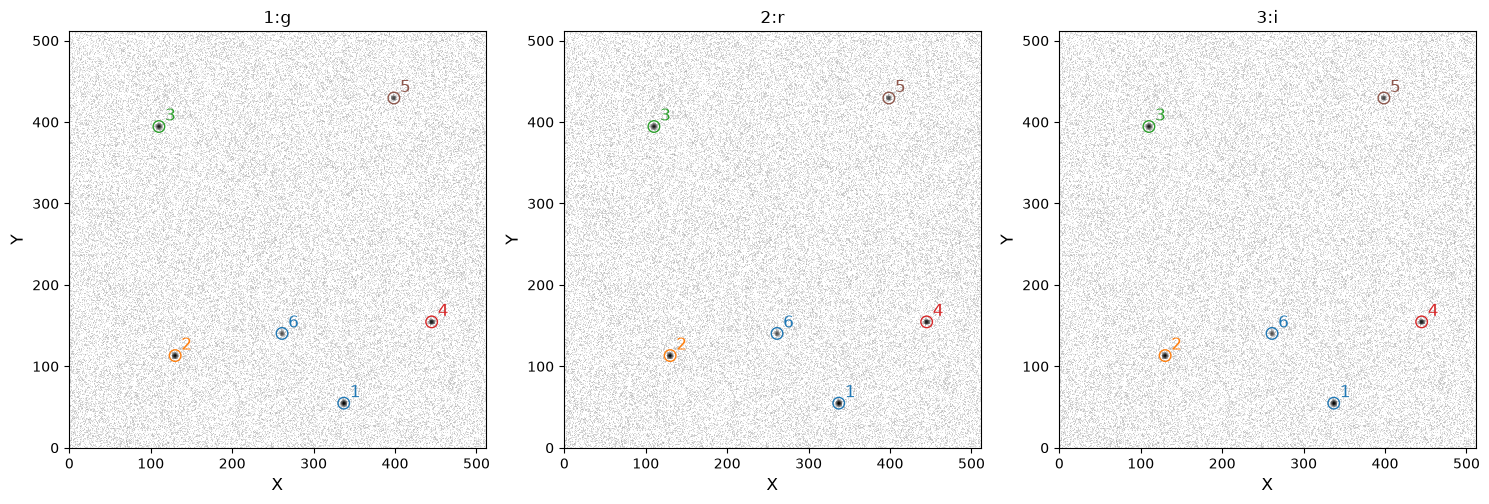

[OPTICAM] Plot saved to /tmp/tmpfoyp37uw/out/reduced/manual_flats/diag/systematics.pdf.


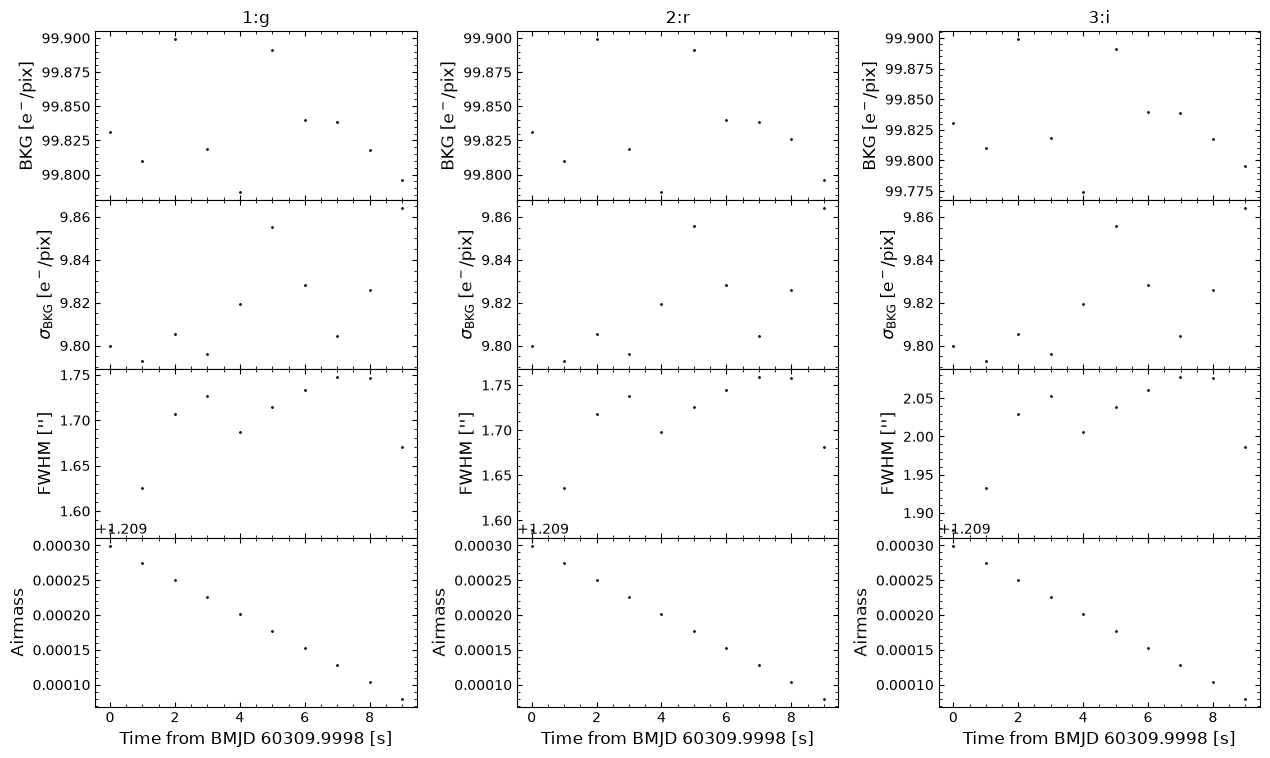

In [12]:
reducer.create_catalogs()

As we can see, the catalog images no longer show an aperture shadow. 

### Creating Master Flats (Short Way)

We can create master flat-field images more easily by letting `phoptic` handle the master flat creation automatically:

[OPTICAM] Scanning data directory:   0%|                                                                                                                              |[00:00<?]

[OPTICAM] Scanning data directory:  67%|█████████████████████████████████████████████████████████████████████████████████▎                                        |[00:00<00:00]

[OPTICAM] Scanning data directory: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:00<00:00]

[OPTICAM] 5 1:g flat-field images.
[OPTICAM] 5 3:i flat-field images.
[OPTICAM] 5 2:r flat-field images.
[OPTICAM] out/reduced/auto_flats not found, attempting to create ...
[OPTICAM] out/reduced/auto_flats created.


[OPTICAM] Scanning data directory:   0%|                                                                                                                              |[00:00<?]

...

[OPTICAM] 10 1:g images.


[OPTICAM] 10 2:r images.


[OPTICAM] 10 3:i images.


[OPTICAM] FlatFieldCorrector sucessfully passed all checks.


[OPTICAM] Plot saved to /tmp/tmpfoyp37uw/out/reduced/auto_flats/diag/header_times.pdf.


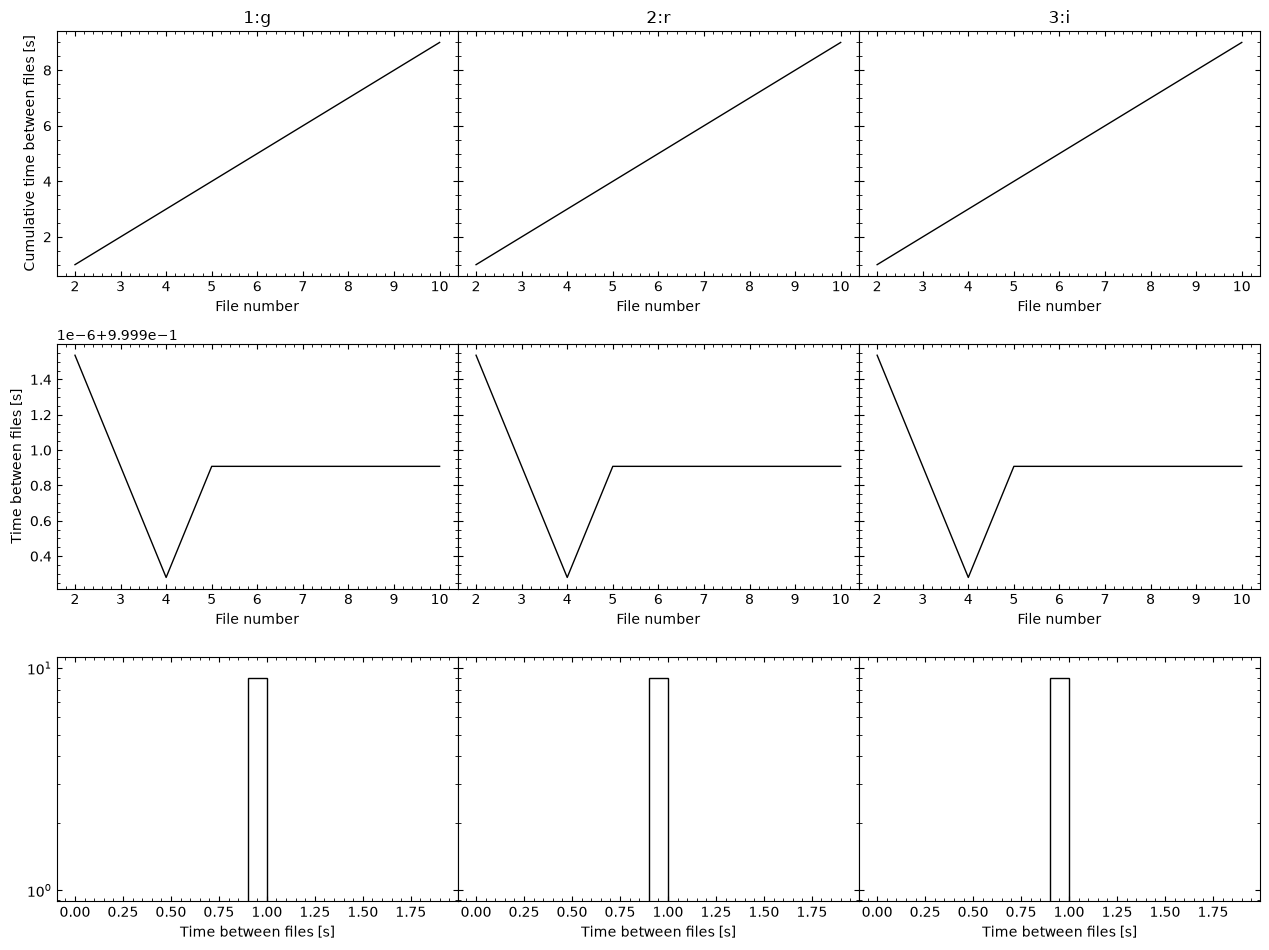

In [13]:
auto_flat_corrector = phoptic.FlatFieldCorrector(
    out_directory=out_dir / 'correctors' / 'auto_flats',  # where the master flat field images will be stored
    data_directory=flats_dir,  # where the flat field images are stored
    )

auto_reducer = phoptic.Reducer(
    data_directory=obs_dir,  # path to the simulated data
    out_directory=out_dir / 'reduced' / 'auto_flats',  # path to where output will be saved
    show_plots=True,
    flat_corrector=auto_flat_corrector,  # pass the flat field corrector
    )

Currently, the flat corrector has not been used, and so if we check for the master flats we will find that they don't yet exist:

In [14]:
auto_reducer.flat_corrector.master_image_path.is_file()

False

However, if we initialise the catalog we will see that the master flats will be created automatically so that they can be applied to the images:

[OPTICAM] Creating source catalogs.


[OPTICAM] 1:g master flat-field image not found. Attempting to create.


[OPTICAM] Master flat-field image(s) created.


[OPTICAM] Master flat-field image(s) saved to out/correctors/auto_flats/master_flats.fits.gz.


[OPTICAM] Aligning 1:g images:   0%|                                                                                                                                  |[00:00<?]

...

[OPTICAM] Aligning 3:i images: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:02<00:00]

[OPTICAM] [OPTICAM] Done.


[OPTICAM] [OPTICAM] 10 image(s) aligned.


[OPTICAM] [OPTICAM] 0 image(s) could not be aligned.


[OPTICAM] Plot saved to /tmp/tmpfoyp37uw/out/reduced/auto_flats/cat/catalogs.pdf.


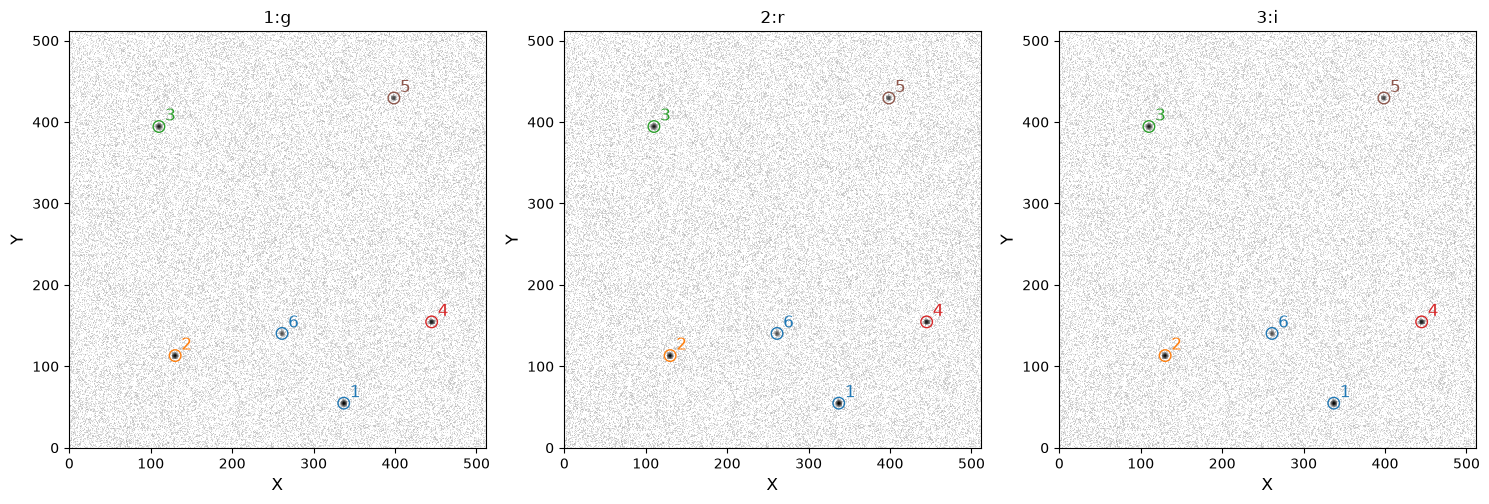

[OPTICAM] Plot saved to /tmp/tmpfoyp37uw/out/reduced/auto_flats/diag/systematics.pdf.


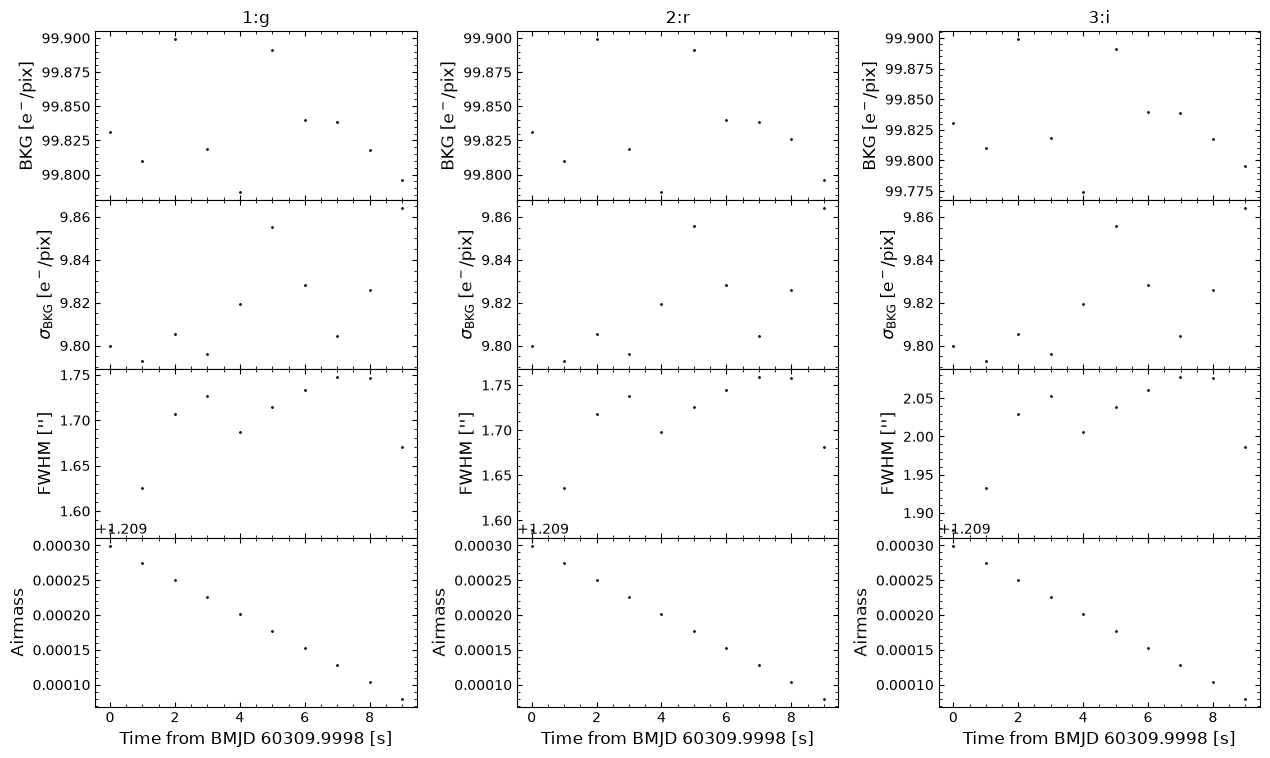

In [15]:
auto_reducer.create_catalogs()

As we can see, the master flats were automatically created so that the corrections could be applied when needed. For completeness, let's also check if the master flats directory now exists:

In [16]:
auto_reducer.flat_corrector.master_image_path.is_file()

True

With just a few lines of code, we have created master flats and used them to correct our observation images!

## Dark noise

OPTICAM-MX images include the nominal dark current in their headers, allowing the dark noise to be calculated by multiplying the dark current by the exposure time. If you're using `phoptic` to reduce data from OPTICAM-MX data, or data from an instrument that measures the dark current, then you can subtract the dark noise by passing an empty `DarkNoiseCorrector` instance to `Reducer`:

[OPTICAM] out/reduced/dark_current not found, attempting to create ...
[OPTICAM] out/reduced/dark_current created.


[OPTICAM] Scanning data directory:   0%|                                                                                                                              |[00:00<?]

[OPTICAM] Scanning data directory: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:00<00:00]

[OPTICAM] Checking instrument OPTICAM_MX.
[OPTICAM] OPTICAM_MX sucessfully passed all checks.


[OPTICAM] Parsing file headers:   0%|                                                                                                                                 |[00:00<?]

...

[OPTICAM] 10 1:g images.


[OPTICAM] 10 2:r images.


[OPTICAM] 10 3:i images.


[OPTICAM] DarkNoiseCorrector sucessfully passed all checks.
[OPTICAM] FlatFieldCorrector sucessfully passed all checks.


[OPTICAM] Plot saved to /tmp/tmpfoyp37uw/out/reduced/dark_current/diag/header_times.pdf.


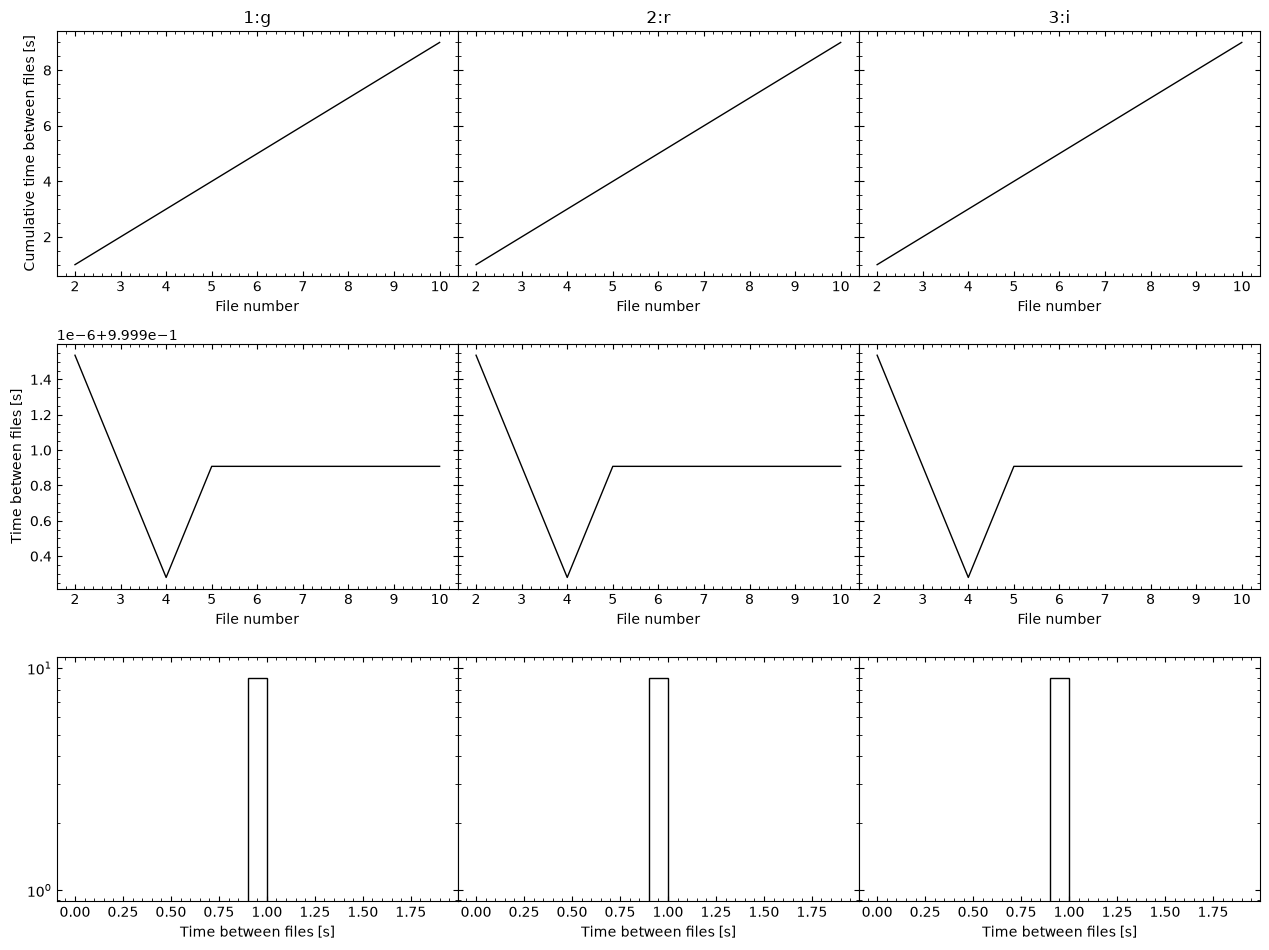

In [17]:
dark_current_reducer = phoptic.Reducer(
    data_directory=obs_dir,  # path to the simulated data
    out_directory=out_dir / 'reduced' / 'dark_current',  # path to where output will be saved
    show_plots=True,
    flat_corrector=auto_flat_corrector,  # pass the flat field corrector
    dark_corrector=phoptic.DarkNoiseCorrector(
        instrument=phoptic.OPTICAM_MX(),
        )
    )

Note that we have passed an `Instrument` instance to `DarkNoiseCorrector`, but no directories. By doing this, `phoptic` will attempt to perform dark noise corrections using the exposure-integrated dark current; as we can see, the `DarkNoiseCorrector` instance passed all checks in this case. For instruments that do not report a dark current value, we'll need to use `DarkNoiseCorrector` to create a master dark image, which will then be subtracted from science images to remove the dark noise. The interface for `phoptic.DarkNoiseCorrector` is pretty much identical to that of `phoptic.FlatFieldCorrector` in this regard.

### Generating Synthetic Darks

To demonstrate how to apply dark noise corrections, we need to generate some dark images. For this example, we'll assume we have observed faint sources using a long exposure time to allow for a considerable dark noise contribution. I'll also ignore any randomness in the dark noise contribution for simplicity:

In [18]:
import numpy as np

IMG_SIZE = (256, 256)
DARK_FLUX = 30.0  # average exposure-integrated dark current contribution
EXPTIME = 120.0  # exposure time in seconds
FLTR = 'U'
BINNING = '1x1'

for i in range(5):
    
    image = np.zeros(IMG_SIZE) + DARK_FLUX
    
    hdu = fits.PrimaryHDU(image)  # image data
    
    hdu.header['FILTER'] = FLTR  # the observation filter
    hdu.header['BINNING'] = BINNING  # the image binning (1x1)
    hdu.header['EXPTIME'] = EXPTIME  # the exposure time in seconds
    hdu.header['INSTRUME'] = 'SYNTHETICAM'
    hdu.header['RDNOISE'] = 0.
    
    save_path = out_dir / 'calibration_images' / 'darks'  # directory to which image will be saved
    
    # create save directory if it does not already exist
    if not save_path.is_dir():
        save_path.mkdir(parents=True)
    
    # save image
    file_path = save_path / f'image_{i}.fits.gz'
    hdu.writeto(file_path, overwrite=True)

Now we have some dark images, we can create a `DarkNoiseCorrector`. To create a `DarkNoiseCorrector`, however, we need to define an `Instrument`: (see the [custom instruments tutorial](instruments.ipynb) for more details):

In [19]:
%%writefile out/custom_routines.py
from astropy.coordinates import EarthLocation
from astropy import units as u

import phoptic


class CustomInstrument(phoptic.Instrument):
    
    def __init__(
        self,
        diameter=1.0 * u.m,
        location = EarthLocation.from_geodetic(
            lon=0.0,
            lat=0.0,
            height=0.0,
            ),
        pixel_scales = {
            'SYNTHETICAM': 1.0,
            },
        ):
        
        super().__init__(
            diameter=diameter,
            location=location,
            pixel_scales=pixel_scales,
            )

Writing out/custom_routines.py


Due to compatibility issues, routines defined inside of IPython notebooks cannot be used by `multiprocessing` (used by `phoptic`). To overcome this issue, we have used the `%%writefile` magic command to write our `CustomInstrument` class to a temporary module called `custom_routines.py` in our `out` directory. This is required in Python $\geq$ 3.14.

In [20]:
from out.custom_routines import CustomInstrument

instrument = CustomInstrument()

dark_corr = phoptic.DarkNoiseCorrector(
    out_directory=out_dir / 'correctors' / 'darks',
    data_directory=out_dir / 'calibration_images' / 'darks',
    instrument=instrument,
    )

[OPTICAM] Scanning data directory:   0%|                                                                                                                              |[00:00<?]

[OPTICAM] Scanning data directory: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:00<00:00]

[OPTICAM] 5 SYNTHETICAM:U dark images.


We can see that our `DarkNoiseCorrector` has detected five U-band dark images. Let's now generate some science images that contain dark noise:

In [21]:
from photutils.datasets import make_100gaussians_image

# load a noiseless simulated HST image
base_image = np.array(make_100gaussians_image(), dtype=np.float64)[:IMG_SIZE[0], :IMG_SIZE[1]]
base_image /= base_image.max()
base_image *= 100

# add dark noise to the image
noisy_image = base_image + DARK_FLUX

for i in range(5):
    hdu.data = noisy_image
    hdu.header['FILTER'] = FLTR  # the observation filter
    hdu.header['BINNING'] = BINNING  # the image binning (1x1)
    hdu.header['EXPTIME'] = EXPTIME  # the exposure time in seconds
    hdu.header['RA'] = '0'  # pointing of the image
    hdu.header['DEC'] = '0'  # pointing of the image
    hdu.header['GAIN'] = 1.0  # instrument gain
    hdu.header['DATE-OBS'] = f'2026-01-01T00:00:0{i}.000'  # date of observation
    hdu.header['AIRMASS'] = 1  # airmass of observation
    
    save_path = out_dir / 'data' / 'darks'  # directory to which image will be saved
    
    # create save directory if it does not already exist
    if not save_path.is_dir():
        save_path.mkdir(parents=True)
    
    # save image
    file_path = save_path / f'image_{i}.fits.gz'
    hdu.writeto(file_path, overwrite=True)

Let's first take a look at the reference image (i.e., without any dark noise):

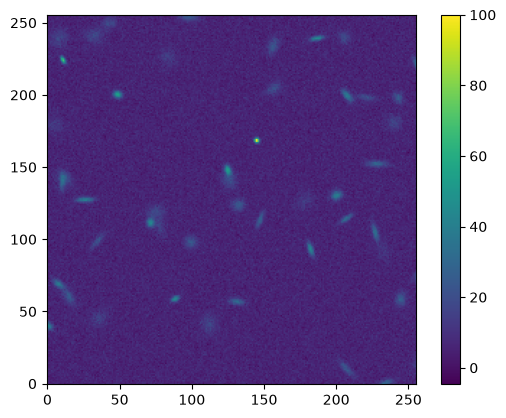

In [22]:
fig, ax = plt.subplots()

im = ax.imshow(base_image, origin='lower')

fig.colorbar(im)

plt.show()

Now let's look at one of the noisy images:

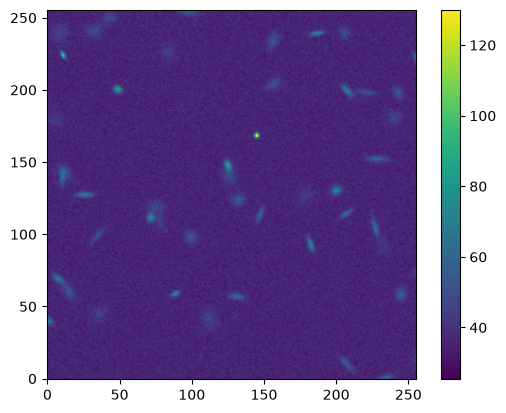

In [23]:
fig, ax = plt.subplots()

im = ax.imshow(noisy_image, origin='lower')

fig.colorbar(im)

plt.show()

While there is no obvious difference from the image alone, because we're assuming uniform dark noise, we can see from the colorbar that the dark noise has increased the flux. Let's compare the fluxes between the two images more explicitly:

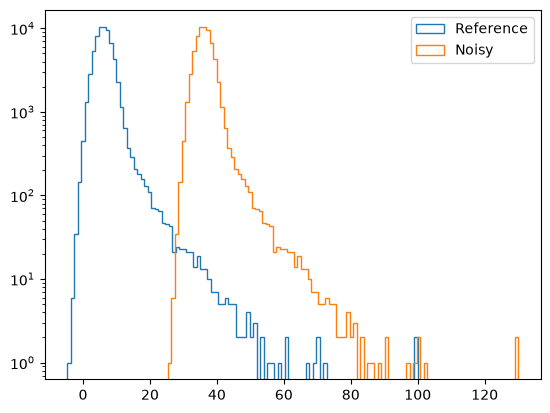

In [24]:
fig, ax = plt.subplots()

ax.hist(
    base_image.flatten(),
    histtype='step',
    bins=100,
    label='Reference',
    )
ax.hist(
    noisy_image.flatten(),
    histtype='step',
    bins=100,
    label='Noisy',
    )

ax.set_yscale('log')

ax.legend()

plt.show()

As we can see, the reference image appears to have a median background flux of $\sim 30$, while the dark noise image has its flux values shifted by the dark flux value of 30. Let's use our `DarkNoiseCorrector` to correct this:

In [25]:
corrected_image, dark_var = dark_corr.correct(
    image=noisy_image,
    camera='SYNTHETICAM',
    fltr=FLTR,
    )

[OPTICAM] SYNTHETICAM:U master dark image not found. Attempting to create.
[OPTICAM] Master dark image(s) created.
[OPTICAM] Master dark image(s) saved to out/correctors/darks/master_darks.fits.gz.


The `correct()` method of `DarkNoiseCorrector` returns the corrected image and the dark noise variance:

In [26]:
dark_var

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(256, 256))

The dark noise variance is zero in this example since our dark images are all identical. In reality, of course, master dark images will have some non-zero variance that will contribute to the photometric error. This is covered in detail in a [dedicated notebook](../tests/calibration_error_propagation.ipynb).

Let's take a look at the corrected image:

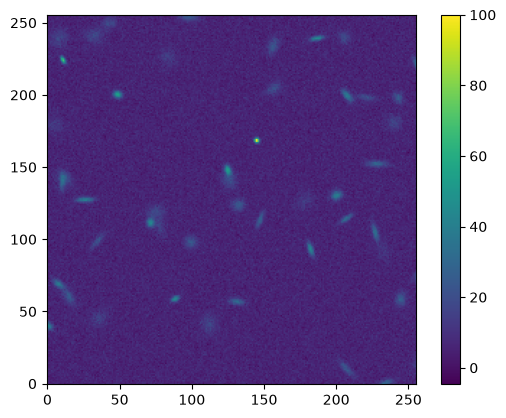

In [27]:
fig, ax = plt.subplots()

im = ax.imshow(corrected_image, origin='lower')

fig.colorbar(im)

plt.show()

From the image alone, the difference isn't immediately obvious. Let's compare the corrected image to the base image more explicitly:

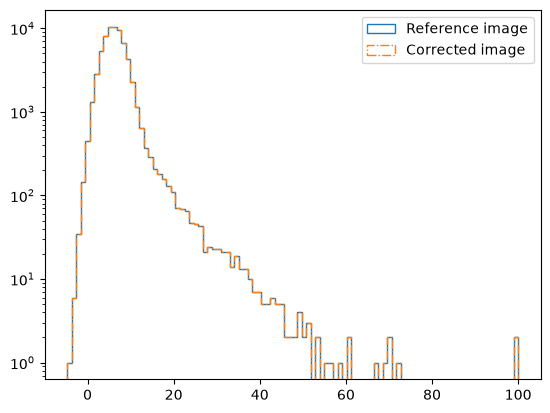

In [28]:
fig, ax = plt.subplots()

ax.hist(
    base_image.flatten(),
    histtype='step',
    bins=100,
    label='Reference image',
    )
ax.hist(
    corrected_image.flatten(),
    histtype='step',
    bins=100,
    label='Corrected image',
    ls='-.',
    )

ax.set_yscale('log')

ax.legend()

plt.show()

In [29]:
assert np.allclose(base_image, corrected_image)

As we can see, the corrected image is now identical to the base image. Of course, in reality noise is random and so it can never be removed perfectly like we have done here. However, this demonstrates how `phoptic.DarkNoiseCorrector` can be used to correct for an instrument's dark noise.

To then use this dark current corrector to reduce some images, we can pass it to a `Reducer` instance as we did for the flat-field corrections. However, since these data have not been designed to mimic OPTICAM-MX data, we'll need to specify custom [source identification](finders.ipynb) and [background estimation](backgrounds.ipynb) routines:

[OPTICAM] out/reduced/darks not found, attempting to create ...
[OPTICAM] out/reduced/darks created.


[OPTICAM] Scanning data directory:   0%|                                                                                                                              |[00:00<?]

[OPTICAM] Scanning data directory: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:00<00:00]

[OPTICAM] Checking instrument CustomInstrument.
[OPTICAM] WARNING: CustomInstrument.dark_curr_kw (DARKCURR) is not a valid header keyword for file /tmp/tmpfoyp37uw/out/data/darks/image_1.fits.gz extension 0. If no dark current is listed in the image headers, you will need to use a `opticam.DarkNoiseCorrector` instance to correct for dark noise. See https://opticam.readthedocs.io/en/latest/_executed/applying_corrections.html#Dark-noise for details.
[OPTICAM] CustomInstrument sucessfully passed all checks.
[OPTICAM] CustomInstrument triggered a warning during 1 check. Warnings may be ignored provided their caveats are satisfied.


[OPTICAM] Parsing file headers:   0%|                                                                                                                                 |[00:00<?]

...

[OPTICAM] Binning: 1x1


[OPTICAM] Filters: SYNTHETICAM:U


[OPTICAM] 5 SYNTHETICAM:U images.


[OPTICAM] DarkNoiseCorrector sucessfully passed all checks.


[OPTICAM] Plot saved to /tmp/tmpfoyp37uw/out/reduced/darks/diag/header_times.pdf.


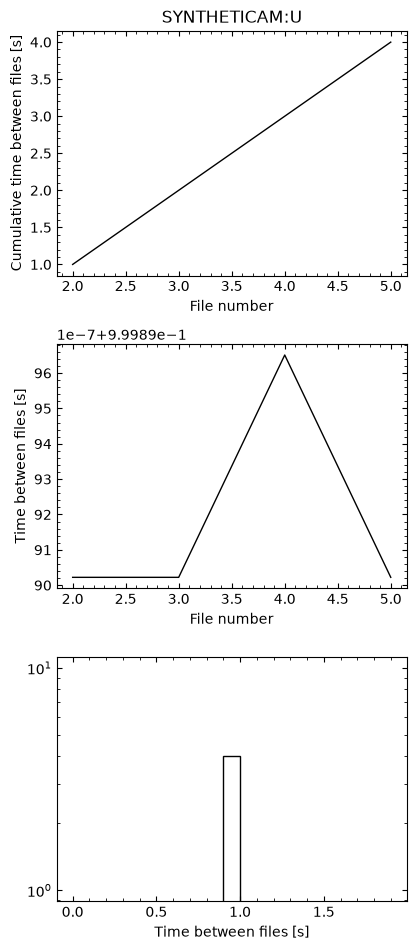

[OPTICAM] Creating source catalogs.


[OPTICAM] Aligning SYNTHETICAM:U images:   0%|                                                                                                                        |[00:00<?]

[OPTICAM] Aligning SYNTHETICAM:U images:  20%|███████████████████████▏                                                                                            |[00:02<00:09]

[OPTICAM] Aligning SYNTHETICAM:U images: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:02<00:00]

[OPTICAM] [OPTICAM] Done.


[OPTICAM] [OPTICAM] 5 image(s) aligned.


[OPTICAM] [OPTICAM] 0 image(s) could not be aligned.


[OPTICAM] Plot saved to /tmp/tmpfoyp37uw/out/reduced/darks/cat/catalogs.pdf.


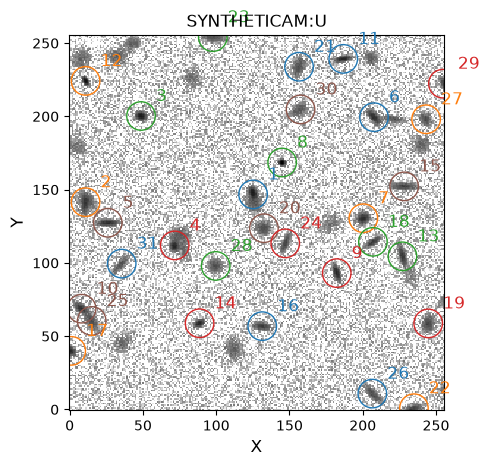

[OPTICAM] Plot saved to /tmp/tmpfoyp37uw/out/reduced/darks/diag/systematics.pdf.


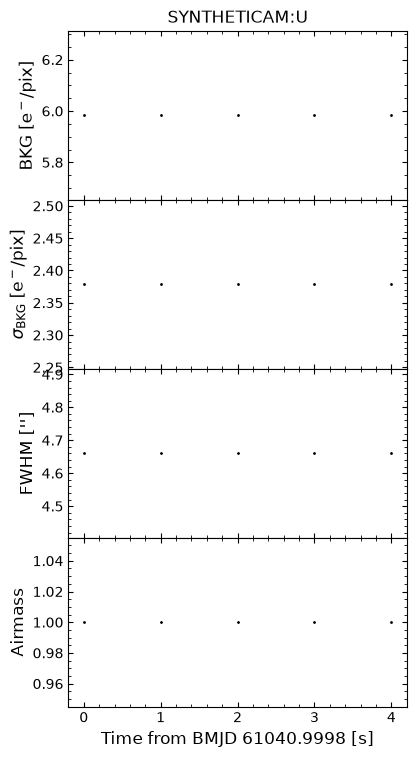

In [30]:
dark_reducer = phoptic.Reducer(
    data_directory=out_dir / 'data' / 'darks',
    out_directory=out_dir / 'reduced' / 'darks',
    show_plots=True,
    dark_corrector=dark_corr,  # pass the dark noise corrector
    instrument=instrument,
    finder=phoptic.DefaultFinder(n_pixels=8),  # specify a custom source finder
    background=phoptic.DefaultBackground(box_size=16),  # specify a custom background estimator
    )

dark_reducer.create_catalogs(
    max_catalog_sources=50,
    n_alignment_sources=50,
    )

As we can see, our `DarkNoiseCorrector` successfully passed all checks. Similarly to `FlatFieldCorrector`, `DarkNoiseCorrector` instances are checked to ensure that any dark images have the same properties as the science images. In particular, `DarkNoiseCorrector` checks that the binning modes, exposure times, and filters all match those of the science images. Additionally, we can see that the median background is $\sim 30$, suggesting that the dark noise has been successfully removed! If the dark noise had not been removed, then the median background would have been closer to $\sim 60$, as we saw earlier.

## Bias Corrections

The OPTICAM-MX cameras perform real-time bias corrections, and so additional bias corrections are nominally not required. If you're using `phoptic` to reduce data from OPTICAM-MX, or another instrument that performs real-time bias corrections, then you can ignore this section. For other instruments, however, a `BiasCorrector` can be used to automate bias correcting. The interface for `phoptic.BiasCorrector` is almost identical to those of `phoptic.FlatFieldCorrector` and `phoptic.BiasCorrector`.

Let's generate some bias images:

In [31]:
BIAS = 100.0

for i in range(3):
    
    image = np.zeros(IMG_SIZE) + BIAS
    
    hdu = fits.PrimaryHDU(image)
    
    hdu.header['BINNING'] = BINNING
    hdu.header['EXPTIME'] = 0.0  # bias images should have an exposure time of 0 s
    hdu.header['INSTRUME'] = 'SYNTHETICAM'
    
    save_path = out_dir / 'calibration_images' / 'biases'  # directory to which image will be saved
    
    # create save directory if it does not already exist
    if not save_path.is_dir():
        save_path.mkdir(parents=True)
    
    # save image
    file_path = save_path / f'image_{i}.fits.gz'
    hdu.writeto(file_path, overwrite=True)

Now let's generate some new dark images. Our previous dark images assumed no bias, which is not the case in reality; our new dark images will therefore contain a bias:

In [32]:
for i in range(3):
    
    image = np.zeros(IMG_SIZE) + DARK_FLUX + BIAS
    
    hdu = fits.PrimaryHDU(image)  # image data
    
    hdu.header['FILTER'] = FLTR  # the observation filter
    hdu.header['BINNING'] = BINNING  # the image binning (1x1)
    hdu.header['EXPTIME'] = EXPTIME  # the exposure time in seconds
    hdu.header['INSTRUME'] = 'SYNTHETICAM'
    
    save_path = out_dir / 'calibration_images' / 'darks_with_bias'  # directory to which image will be saved
    
    # create save directory if it does not already exist
    if not save_path.is_dir():
        save_path.mkdir(parents=True)
    
    # save image
    file_path = save_path / f'image_{i}.fits.gz'
    hdu.writeto(file_path, overwrite=True)

Now let's generate some science images with both bias and dark noise contributions:

In [33]:
# add dark noise to the image
noisy_image = base_image + DARK_FLUX + BIAS

for i in range(10):
    hdu.data = noisy_image
    hdu.header['FILTER'] = FLTR  # the observation filter
    hdu.header['BINNING'] = BINNING  # the image binning (1x1)
    hdu.header['EXPTIME'] = EXPTIME  # the exposure time in seconds
    hdu.header['RA'] = '0'  # pointing of the image
    hdu.header['DEC'] = '0'  # pointing of the image
    hdu.header['GAIN'] = 1.0  # instrument gain
    hdu.header['DATE-OBS'] = f'2026-01-01T00:00:0{i}.000'  # date of observation
    hdu.header['INSTRUME'] = 'SYNTHETICAM'
    
    save_path = out_dir / 'data' / 'darks_with_bias'  # directory to which image will be saved
    
    # create save directory if it does not already exist
    if not save_path.is_dir():
        save_path.mkdir(parents=True)

    # save image
    file_path = save_path.joinpath(f'image_{i}.fits.gz')
    hdu.writeto(file_path, overwrite=True)

Let's compare the image with the noisy image:

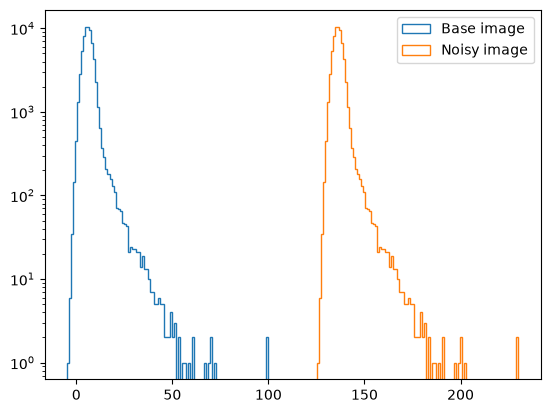

In [34]:
fig, ax = plt.subplots()

ax.hist(
    base_image.flatten(),
    histtype='step',
    bins=100,
    label='Base image',
    )
ax.hist(
    noisy_image.flatten(),
    histtype='step',
    bins=100,
    label='Noisy image',
    )

ax.set_yscale('log')

ax.legend()

plt.show()

As we can see, there is a large offset between the base and noisy images since the noisy image now includes a bias offset in addition to the dark noise from previous example. Let's correct this:

In [35]:
bias_corr = phoptic.BiasCorrector(
    out_directory=out_dir / 'correctors' / 'biases',
    data_directory=out_dir / 'calibration_images' / 'biases',
    instrument=instrument,
    )

dark_corr = phoptic.DarkNoiseCorrector(
    out_directory=out_dir / 'correctors' / 'darks_with_bias',
    data_directory=out_dir / 'calibration_images' / 'darks_with_bias',
    instrument=instrument,
    )

[OPTICAM] Scanning data directory:   0%|                                                                                                                              |[00:00<?]

[OPTICAM] Scanning data directory: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:00<00:00]

[OPTICAM] 3 SYNTHETICAM bias images.


[OPTICAM] Scanning data directory:   0%|                                                                                                                              |[00:00<?]

[OPTICAM] Scanning data directory: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:00<00:00]

[OPTICAM] 3 SYNTHETICAM:U dark images.


In [36]:
bias_corrected_image, bias_var = bias_corr.correct(
    image=noisy_image,
    camera='SYNTHETICAM'
    )

[OPTICAM] SYNTHETICAM master bias image not found. Attempting to create.
[OPTICAM] Master bias image(s) created.
[OPTICAM] Master bias image(s) saved to out/correctors/biases/master_bias.fits.gz.


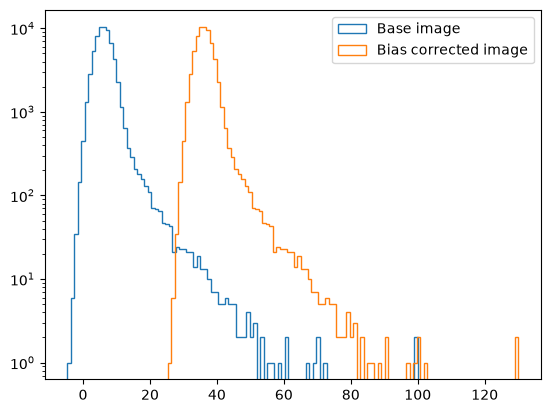

In [37]:
fig, ax = plt.subplots()

ax.hist(
    base_image.flatten(),
    histtype='step',
    bins=100,
    label='Base image',
    )
ax.hist(
    bias_corrected_image.flatten(),
    histtype='step',
    bins=100,
    label='Bias corrected image',
    )

ax.set_yscale('log')

ax.legend()

plt.show()

We can see that the offset is smaller, but not yet zero (because we also have a dark noise contribution). Let's correct this using our new dark noise corrector:

In [38]:
bias_and_dark_corrected_image, dark_var = dark_corr.correct(
    image=bias_corrected_image,
    camera='SYNTHETICAM',
    fltr='U',
    )

[OPTICAM] SYNTHETICAM:U master dark image not found. Attempting to create.
[OPTICAM] Master dark image(s) created.
[OPTICAM] Master dark image(s) saved to out/correctors/darks_with_bias/master_darks.fits.gz.


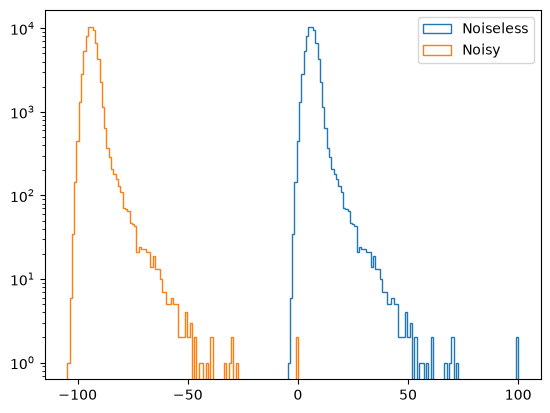

In [39]:
fig, ax = plt.subplots()

ax.hist(
    base_image.flatten(),
    histtype='step',
    bins=100,
    label='Noiseless',
    )
ax.hist(
    bias_and_dark_corrected_image.flatten(),
    histtype='step',
    bins=100,
    label='Noisy',
    )

ax.set_yscale('log')

ax.legend()

plt.show()

Uh oh, we have negative fluxes! This is because the bias contribution is being subtracted twice: once by the master bias and again by the master dark. To fix this, we can pass a `BiasCorrectorInstance` to `DarkNoiseCorrector`:

In [40]:
new_dark_corr = phoptic.DarkNoiseCorrector(
    out_directory=out_dir / 'correctors' / 'bias-corrected_darks',
    data_directory=out_dir / 'calibration_images' / 'darks_with_bias',
    instrument=instrument,
    bias_corrector=bias_corr,
    )

new_dark_corr.create_master_images()

[OPTICAM] Scanning data directory:   0%|                                                                                                                              |[00:00<?]

[OPTICAM] Scanning data directory: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:00<00:00]

[OPTICAM] 3 SYNTHETICAM:U dark images.
[OPTICAM] Master dark image(s) created.
[OPTICAM] Master dark image(s) saved to out/correctors/bias-corrected_darks/master_darks.fits.gz.


In [41]:
bias_and_dark_corrected_image_new, dark_var = new_dark_corr.correct(
    image=bias_corrected_image,
    camera='SYNTHETICAM',
    fltr='U',
    )

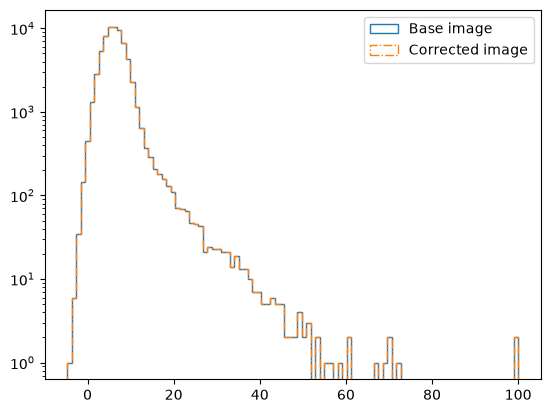

In [42]:
fig, ax = plt.subplots()

ax.hist(
    base_image.flatten(),
    histtype='step',
    bins=100,
    label='Base image',
    )
ax.hist(
    bias_and_dark_corrected_image_new.flatten(),
    histtype='step',
    bins=100,
    label='Corrected image',
    ls='-.',
    )

ax.set_yscale('log')

ax.legend()

plt.show()

In [43]:
assert np.allclose(base_image, bias_and_dark_corrected_image_new)

Now the corrected image is identical to the reference image! Again, however, it's worth stressing that noise is *random*, and so in practise it will never be removed perfectly as it has been here.

## Calibrating calibration images

Above, we saw that it is necessary to bias-correct dark images. Of course, the same is also true for flat-field images. Additionally, it may be necessary to subtract the dark noise contribution from your flats if they require a longer exposure time and/or your instrument has a high dark current. Let's generate some flats that contain bias and dark noise contributions:

In [44]:
for i in range(3):
    image = np.ones(IMG_SIZE) + DARK_FLUX + BIAS

    hdu = fits.PrimaryHDU(image)  # image data

    hdu.header['FILTER'] = FLTR  # the observation filter
    hdu.header['BINNING'] = BINNING  # the image binning (1x1)
    hdu.header['EXPTIME'] = EXPTIME  # the exposure time in seconds
    hdu.header['INSTRUME'] = 'SYNTHETICAM'

    save_path = out_dir / 'calibration_images' / 'flats_with_bias_and_dark_noise'  # directory to which image will be saved

    # create save directory if it does not already exist
    if not save_path.is_dir():
        save_path.mkdir(parents=True)

    # save image
    file_path = save_path / f'image_{i}.fits.gz'
    hdu.writeto(file_path, overwrite=True)

These flats have a flux of 1 (to avoid division by zero) before bias and dark noise contributions are added. As such, the master flat-field image should also have a flux of 1 (assuming the bias and dark noise are corrected properly):

In [45]:
flat_corr = phoptic.FlatFieldCorrector(
    out_directory=out_dir / 'correctors' / 'bias-corrected_and_dark-subtracted_flats',
    data_directory=save_path,
    bias_corrector=bias_corr,  # pass bias corrector
    dark_corrector=new_dark_corr,
    instrument=instrument,
    )

flat_corr.create_master_images()

print(flat_corr.master_images['SYNTHETICAM:U'])

[OPTICAM] Scanning data directory:   0%|                                                                                                                              |[00:00<?]

[OPTICAM] Scanning data directory: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:00<00:00]

[OPTICAM] 3 SYNTHETICAM:U flat-field images.
[OPTICAM] Master flat-field image(s) created.
[OPTICAM] Master flat-field image(s) saved to out/correctors/bias-corrected_and_dark-subtracted_flats/master_flats.fits.gz.
[[1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 ...
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]]


In [46]:
assert np.allclose(flat_corr.master_images['SYNTHETICAM:U'], 1.)

As we can see, all the pixels of the master flat have a flux of 1, suggesting that the bias and dark contributions were successfully removed.

When passing a `DarkNoiseCorrector` instance to `FlatFieldCorrector`, `phoptic` also checks that the exposure times of the flats matches those of the darks; if they exposure times do not match, an error is raised:

In [47]:
for i in range(3):
    image = np.ones(IMG_SIZE) + DARK_FLUX + BIAS
    
    hdu = fits.PrimaryHDU(image)  # image data
    
    hdu.header['FILTER'] = FLTR  # the observation filter
    hdu.header['BINNING'] = BINNING  # the image binning (1x1)
    hdu.header['EXPTIME'] = 3.  # the exposure time in seconds
    hdu.header['INSTRUME'] = 'SYNTHETICAM'
    
    save_path = out_dir / 'calibration_images' / 'short-exposure_flats_with_bias_and_dark'  # directory to which image will be saved
    
    # create save directory if it does not already exist
    if not save_path.is_dir():
        save_path.mkdir(parents=True)
    
    # save image
    file_path = save_path / f'image_{i}.fits.gz'
    hdu.writeto(file_path, overwrite=True)

In [48]:
flat_corr = phoptic.FlatFieldCorrector(
    out_directory=out_dir / 'correctors' / 'short-exposure_flats',
    data_directory=save_path,
    bias_corrector=bias_corr,  # pass bias corrector
    dark_corrector=new_dark_corr,
    instrument=instrument,
    )

try:
    flat_corr.create_master_images()
except Exception as e:
    print(f'ERROR: {e}')

[OPTICAM] Scanning data directory:   0%|                                                                                                                              |[00:00<?]

[OPTICAM] Scanning data directory: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████|[00:00<00:00]

[OPTICAM] 3 SYNTHETICAM:U flat-field images.
ERROR: [OPTICAM] inconsistent exposure times between flat-field images and dark images. Flat-field exposure time: 3.0 s; dark exposure time: 120.0 s.


As we can see, the master flat-field image could not be created due to incompatible exposure times between the dark and flat-field images.

That concludes the corrections tutorial for `phoptic`! For simplicity, we largely ignored the randomness of noise and, as such, did not discuss how `phoptic` propagates errors during calibration. To see `phoptic`'s calibration error propagation in action, there is a [dedicated notebook](../tests/calibration_error_propagation.ipynb).